**This notebook builds an end-to-end multi-class image classifier using TensorFlow 2.0 and TensorFlow Hub.**

## 1. Problem

Identifying the breed of a dog given an image of a dog.

## 2. Data

The data that I am using is from Kaggle's dog breed identification.

## 3. Evaluation

The evaluation is a file with prediction probabilities for each dog breed of each test image.

## 4.Features

Some information about the data:
* We're dealing with images(unstructed data)
* There are 120 breeds of dogs(this means there are 120 different classes).
* There are around 10,000+ images in the training set and Test set
*Training set has label. while test set do not.



In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

import tensorflow_hub as hub
import pandas as pd
import numpy as np


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#!unzip "/content/drive/MyDrive/dog_breed_data/d og-breed-identification (2).zip" -d "/content/drive/MyDrive/dog_breed_data"

# Get Our workspace ready!

In [5]:
import tensorflow as tf
print("TF version", tf.__version__)

TF version 2.21.0


In [6]:
import tensorflow_hub as hub
print("Tf Hub version:", hub.__version__)

##check for GPU availability
print("GPU", "available (yesss)" if tf.config.list_physical_devices("GPU") else "not available")


Tf Hub version: 0.16.1
GPU available (yesss)


## Getting our data ready (turning it into tensors)


In [7]:
import pandas as pd

labels_csv = pd.read_csv("/content/drive/MyDrive/dog_breed_data/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


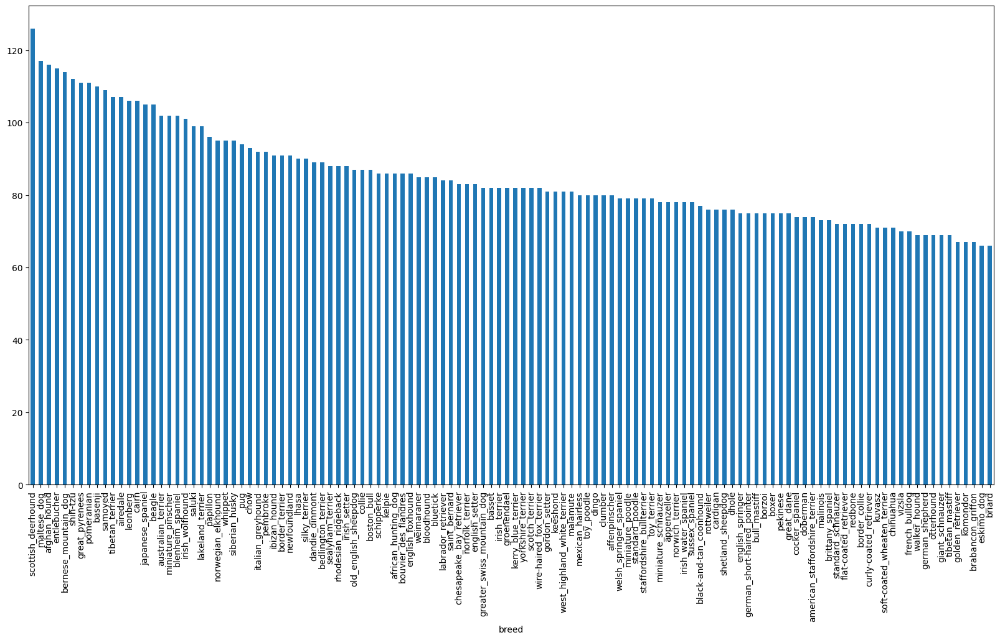

In [8]:
labels_csv["breed"].value_counts().plot.bar(figsize = (20,10));

In [9]:
labels_csv["breed"].value_counts().median()

82.0

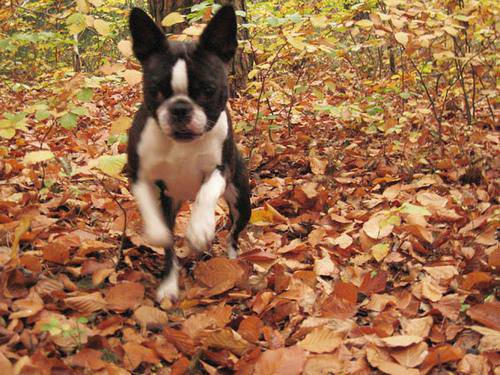

In [10]:


from IPython.display import Image
Image(filename='/content/drive/MyDrive/dog_breed_data/train/000bec180eb18c7604dcecc8fe0dba07.jpg')


##Getting images and their labels



In [11]:
labels_csv.head()



,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [12]:
filenames = ["/content/drive/My Drive/dog_breed_data/train/" + fname for fname in labels_csv["id"]+ ".jpg"]
filenames[:10]

['/content/drive/My Drive/dog_breed_data/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/My Drive/dog_breed_data/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/My Drive/dog_breed_data/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/My Drive/dog_breed_data/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/My Drive/dog_breed_data/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/content/drive/My Drive/dog_breed_data/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/content/drive/My Drive/dog_breed_data/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/content/drive/My Drive/dog_breed_data/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/content/drive/My Drive/dog_breed_data/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '/content/drive/My Drive/dog_breed_data/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [13]:
import os
os.listdir("drive/My Drive/dog_breed_data/train/")[:10]


['e996402cf7fa66f23a8415c9007e06db.jpg',
 'e0f1273a2ed4e1790bd92880d0651893.jpg',
 'e85f6d7af1405365c8e576d0a0aa7a2b.jpg',
 'e2d770fe32772edb9dba937c009f3e4d.jpg',
 'e17f3e7d3d1468c34643e60cb622e935.jpg',
 'dd10fca78ab9624a15f55293c36ad292.jpg',
 'e17462ffe48dffec8ff70325a6047957.jpg',
 'e073b458a33cbfe9b733764a1246f52e.jpg',
 'e3cc185776379b55e23a9973bce785b7.jpg',
 'e66b165e767d45ac2ef046873a27ed29.jpg']

In [14]:
#Check whether number of filenames matches number of actual image files
import os
if len(os.listdir("drive/My Drive/dog_breed_data/train/")) == len(filenames):
  print("Filenames match actual amount of files !! Proceed")
else:
  print("Filenames doesnot match actual number of files, check the target directory")

Filenames match actual amount of files !! Proceed


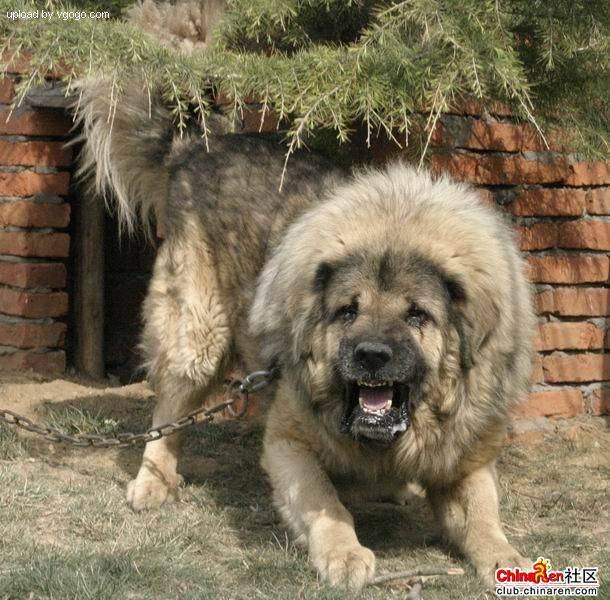

In [15]:
current_id_at_9000 = labels_csv["id"].iloc[9000]
correct_filename = f"/content/drive/My Drive/dog_breed_data/train/{current_id_at_9000}.jpg"
Image(correct_filename)

In [16]:
labels_csv["breed"][9000]

'tibetan_mastiff'

Since we have our file paths in the list, lets prepare labels.

In [17]:
import numpy as np
labels = labels_csv["breed"]
labels = np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [18]:
len(labels)

10222

In [19]:
if len(labels) == len(filenames):
  print("yes!! number of labels matches number of files")
else:
  print("no they dont match")

yes!! number of labels matches number of files


In [20]:
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [21]:
len(unique_breeds)

120

In [22]:
print(labels[0])
labels[0] == unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [23]:
#Turn every label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [24]:
len(boolean_labels)

10222

In [25]:
#Turning boolean array into integers
print(labels[0])
print(np.where(unique_breeds == labels[0]))
print(boolean_labels[0].argmax())
print(boolean_labels[0].astype(int))

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [26]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


##Creating our own validation set

since the dataset from Kaggle doesn't vome with a validation set. we are going to create own own.

In [27]:
X = filenames
y = boolean_labels

experimenting for 1000 images with images and then increasing as needed.

In [28]:

NUM_IMAGES = 1000 #@param {type:"slider", min:1000, max:10000}

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X[: NUM_IMAGES], y[:NUM_IMAGES], test_size = 0.2, random_state = 42)

len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

In [30]:
X_train[:2], y_train[:2]

(['/content/drive/My Drive/dog_breed_data/train/00bee065dcec471f26394855c5c2f3de.jpg',
  '/content/drive/My Drive/dog_breed_data/train/0d2f9e12a2611d911d91a339074c8154.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, Fal

##Preprocessing Images(turning images into tensors)


Preprocessing Images(turning images into tensors)
To preprocess images into Tensors there is going to be a function which will do a few things:
1. Take an image filepath as input
2. Use tensorflow to read the file and save it to a variable, 'image'
3. turn the 'image' (a jpg file) into Tensors
4.Normalize the image by converting the iamge channel values from 0 to 255 to 0 to 1.
5. Resize the 'image' to be a shape of (224, 224)
6. Return the modified image

In [31]:
#convert image to numpy array
from matplotlib.pyplot import imread
image = imread(filenames[42])
image.shape



(257, 350, 3)

In [32]:
image.max(), image.min()


(np.uint8(255), np.uint8(0))

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]],

       [[ 56, 104,  66],
        [ 58, 106,  68],
        [ 64, 112,  74],
        ...,
        [ 71, 127,  82],
        [ 73, 129,  84],
        [ 74, 130,  85]],

       ...,

       [[  2,  11,  10],
        [  5,  14,  11],
        [  8,  14,  14],
        ...,
        [120, 113,  67],
        [126, 118,  71],
        [122, 114,  67]],

       [[  0,   3,   7],
        [  2,   7,  10],
        [  3,   9,   7],
        ...,
        [105,  98,  54],
        [112, 104,  58],
        [111, 103,  57]],

       [[ 16,  18,  30],
        [ 16,  19,  24],
        [ 15,  20,  14],
        ...,
        [101,  92,  51],
        [ 97,  88,  47],
        [120, 111,  70]]], dtype=uint8)
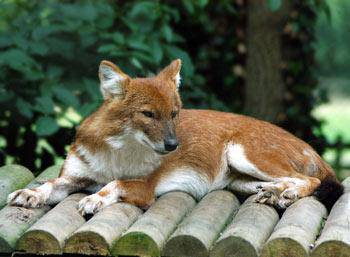

In [33]:
image


In [34]:
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

In [35]:
#Define image size
IMG_SIZE = 224

def process_image(image_path, IMG_SIZE = 224):
  """
  Take an imagefile path and turns an image into a tensor of fixed size

  """
  # Read in an image file
  image = tf.io.read_file(image_path)
 # Turn the jpeg image into numerical Tensor with 3 colour channels (Red, Green, Blue)
  image = tf.image.decode_jpeg(image, channels = 3)
  #convert the colour channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
 # resizing the image
  image = tf.image.resize(image, size = [IMG_SIZE, IMG_SIZE])
  return image



##Turning Data Into Batches

In [36]:
#Function to return a tuple of tensors

def get_image_label(image_path, label):
  """
  this function takes image file path name and the associated label,
  processes the image and returns a tuple of (image, label)).

  """
  image = process_image(image_path)
  return image, label

In [37]:
(process_image(X[42]), y[42] )

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117757],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

NOW we are going to turn data into tuples of tensors in the form (image, label). Lets make a function to turn all of our data (x & y) into batches!

In [38]:
#Define batch size to 32
BATCH_SIZE = 32

def create_data_batches(X, y = None, batch_size = BATCH_SIZE, valid_data = False, test_data = False):
  """
  Creates batches of data out of image (x) and label (y) pairs.
  Shuffles the data if it's training but shuffle if its validation data.
  Also accepts test data as input (no labels).
  """
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices(tf.constant(X))
    data_batch = data.map(process_image).batch(BATCH_SIZE)
    return data_batch
  #if data is a validation set dont suffle it.
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch
  else:
    print("Creating for training data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(y)))
    #Shuffling pathnames and labels before mapping image processor function is faster than shuffling after it.
    data = data.shuffle(buffer_size = len(X))
    data = data.map(get_image_label)
    data_batch = data.batch(BATCH_SIZE)
    return data_batch


In [39]:
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val,y_val, valid_data = True)

Creating for training data batches...
Creating validation data batches...


In [40]:
# attributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

##Visualizing Data Batches

In [41]:
import matplotlib.pyplot as plt

def show_25_images(images, labels):
  """
  Displays a plot of 25 images and their labels form a data batch
  """
  plt.figure(figsize = (15, 15))

  for i in range(25):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i])
    plt.title(unique_breeds[labels[i].argmax()])
    plt.axis("off")


In [42]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [43]:
train_images, train_labels = next(train_data.as_numpy_iterator())
len(train_images), len(train_labels)
#because our batch isze was 32

(32, 32)

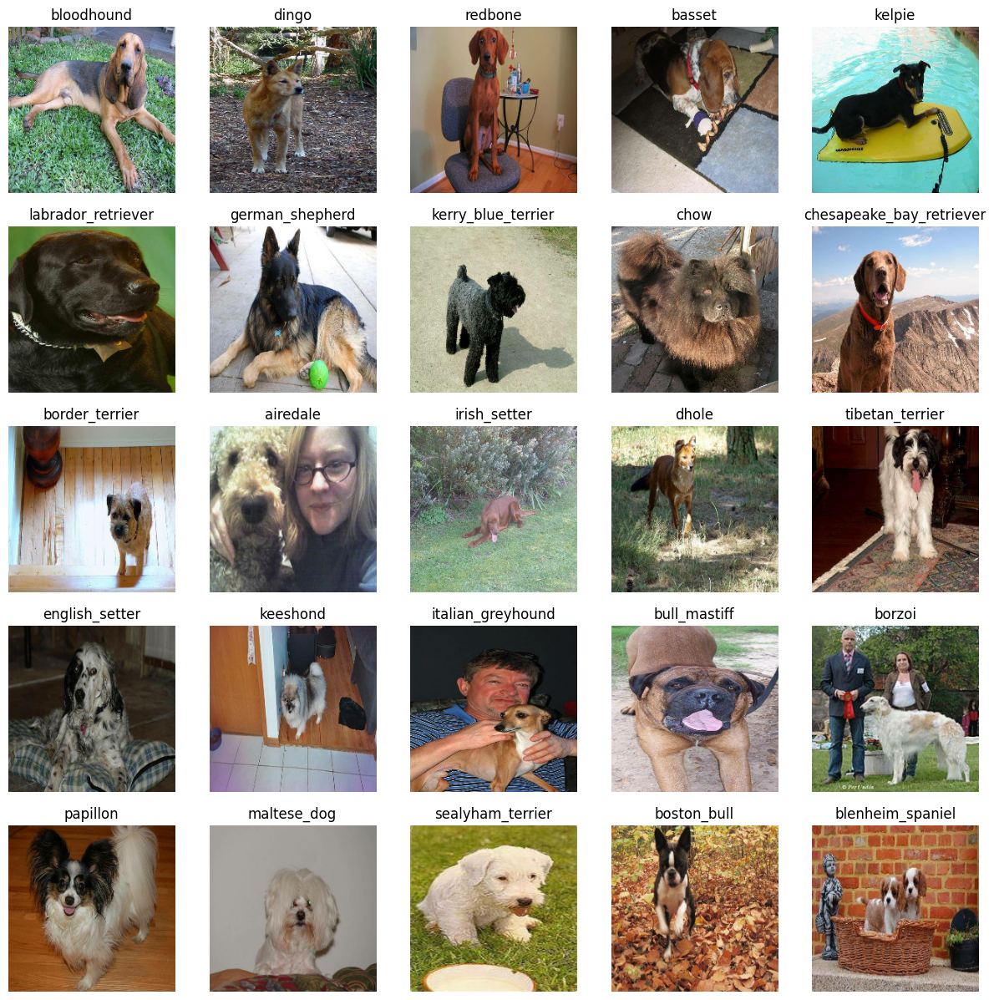

In [44]:
show_25_images(train_images, train_labels)

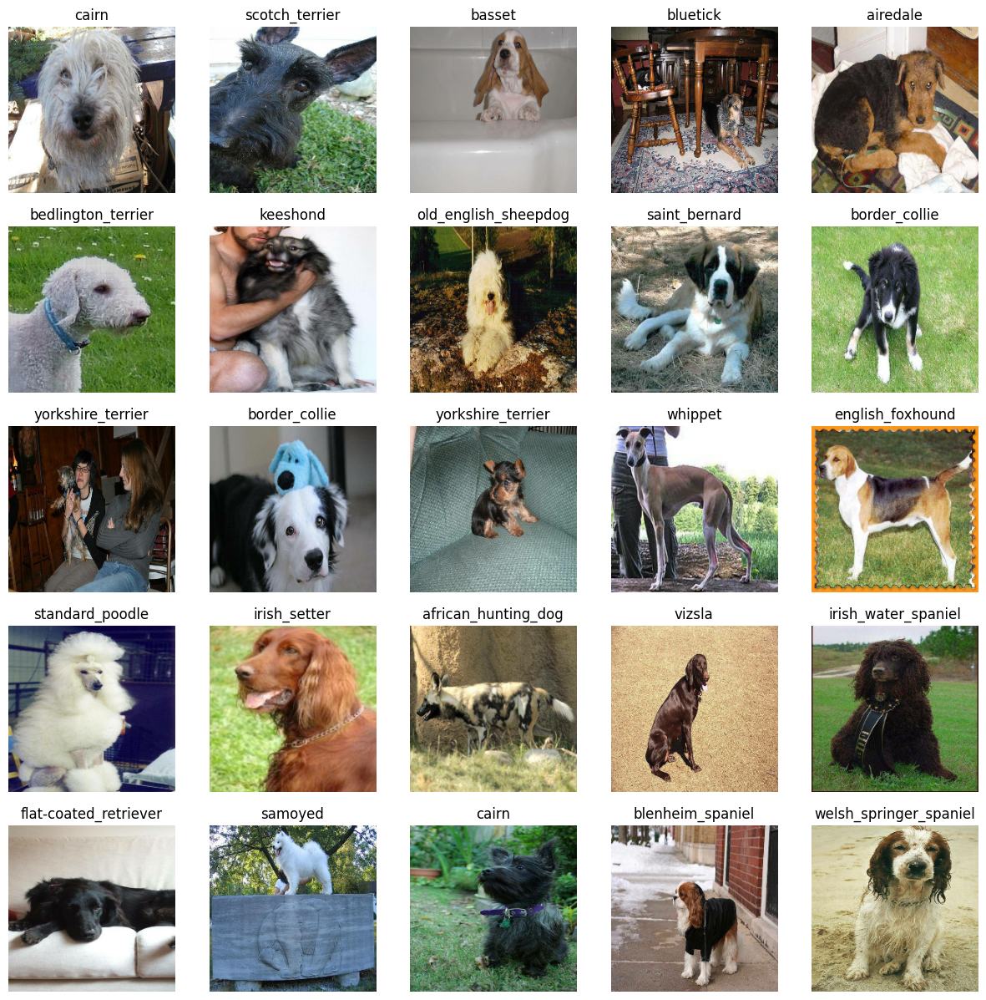

In [45]:
##Visualizing validation data
valid_images, valid_labels = next(val_data.as_numpy_iterator())
show_25_images(valid_images, valid_labels)

## BUILDING A MODEL
Before we build model , there are a few things we need to define:
* The input shape (our images, in the form of Tensors) to our model.

* The outpjt shape(image lables, in form of Tensors) of our model.

* The URL of the model we want to use.

In [46]:
INPUT_SHAPE = [None, IMG_SIZE , IMG_SIZE, 3] # batch, rows or height, width or cols, colour channels in each
OUTPUT_SHAPE = len(unique_breeds)
# Setup model URL from Tensorflow Hub
MODEL_URL = "https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4"

Now we got our inputs, outputs and model ready to go. putting them together into a keras deep learning model.
knowing this , let's create a function:

* Takes the input shape, output shape and the model we've chosen as parameters.
* Defines the layers in a keras model in sequential fashion (do this first, then this, then that)
* compile the model
* Builds the model
* Returns the model.


In [47]:
#Create a function which builds a keras model
def create_model(input_shape = INPUT_SHAPE, output_shape = OUTPUT_SHAPE, model_url = MODEL_URL):
  print("Building model with:", MODEL_URL)

  #Setup the model layers
  model = tf.keras.Sequential([
    hub.KerasLayer(MODEL_URL), # Layer1 input layer
    tf.keras.layers.Dense(units = OUTPUT_SHAPE, # Layer2 output layer
                          activation = "softmax")
  ])

  model.compile(
      loss = tf.losses.CategoricalCrossentropy(),
      optimizer = tf.keras.optimizers.Adam(),
      metrics = ["accuracy"]
  )
  model.build(INPUT_SHAPE)
  return model


In [48]:
model = create_model()
model.summary()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1001)              5432713   
                                                                 
 dense (Dense)               (None, 120)               120240    
                                                                 
Total params: 5552953 (21.18 MB)
Trainable params: 120240 (469.69 KB)
Non-trainable params: 5432713 (20.72 MB)
_________________________________________________________________


## Creating callbacks

callbacks are helper functions a model during training to do such things such as save its progress or stop training early if a model stops improving.

Creating 2 callbacks , one for tensorboard which helps track our models progress and another early stopping which prevents our model from training for too long.

## TensorBoard Callback
To set tensorboard callback, we need 3 things
1. Load the tensorboard notebook extensions
2. create a TensorBoard callback which is able to save logs to directory and pass it our model's fit() function.
3. Visualize our models training los with the standard %tensorboard magic function .

In [49]:
import tensorboard
# Load TensorBoard notebook extension
%load_ext tensorboard

In [50]:
import datetime


# Function for a tensorboard callback
def create_tensorboard_callback():
  # Using %m for month and %M for minutes
  logdir = os.path.join("/content/drive/MyDrive/dog_breed_data/logs",
                        datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

  return tf.keras.callbacks.TensorBoard(logdir)

### Early stopping callback

Early stopping help stop our model from overfitting by stopping training if certain evaluation metric stops improving.



In [51]:
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor = "val_accuracy",
                                                     patience = 3)

## Traning a model (on a subset of data)

Our first model is going to train on 1000 images, to make sure everything is working.

In [52]:
NUM_EPOCHS = 100 #@param{type:"slider", min:10, max:100, step:10}

In [53]:
#check to make sure if running on a gpu
if tf.config.list_physical_devices('GPU'):
  print("yes, using gpu")
else:
  print("GPU not found")

yes, using gpu


Creating a function which trains a model
.
* create a model using "create_model()"
* Setup a TensorBoard callback using "create_tensorboard_callback()"
* call the fit() function on our model passing it the training data, validation data, number of epoches and callbacks.
* return the model

In [54]:
def train_model():
  """
  Trains a given model and returns a trained version
  """
  #create a model
  model = create_model()

  #create new TensorBoard session everytime we train a model
  tensorboard = create_tensorboard_callback()

  # Fit the model to the data
  model.fit(x = train_data,
            epochs = NUM_EPOCHS,
            validation_data = val_data,
            validation_freq = 1,
            callbacks = [tensorboard, stopping_callback])
  return model

In [55]:
model = train_model()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Epoch 1/100
25/25 [==============================] - 187s 7s/step - loss: 4.8197 - accuracy: 0.0700 - val_loss: 3.5671 - val_accuracy: 0.2300
Epoch 2/100
25/25 [==============================] - 4s 166ms/step - loss: 1.7661 - accuracy: 0.6550 - val_loss: 2.2702 - val_accuracy: 0.4850
Epoch 3/100
25/25 [==============================] - 5s 189ms/step - loss: 0.6185 - accuracy: 0.9275 - val_loss: 1.7492 - val_accuracy: 0.5900
Epoch 4/100
25/25 [==============================] - 3s 113ms/step - loss: 0.2738 - accuracy: 0.9837 - val_loss: 1.5382 - val_accuracy: 0.6350
Epoch 5/100
25/25 [==============================] - 4s 148ms/step - loss: 0.1578 - accuracy: 0.9962 - val_loss: 1.4516 - val_accuracy: 0.6250
Epoch 6/100
25/25 [==============================] - 3s 124ms/step - loss: 0.1068 - accuracy: 0.9962 - val_loss: 1.3948 - val_accuracy: 0.6300
Epoch 7/100
25/25 [==============================]

Since the model is overfitting because its performing far better on the training dataset than the validation dataset. we use few ways to prevent the model overfitting in deep learning neural networks.

Checking the TensorBoard Logs

The TensorBoard magic function (%tensorboard) will access the logs directory we created earlier and visualize its contents.

In [56]:
%tensorboard --logdir /content/drive/MyDrive/dog_breed_data/logs

<IPython.core.display.Javascript object>

 ## Making and evaluating predictions using trained model

In [57]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [58]:
predictions = model.predict(val_data, verbose = 1)
predictions

7/7 [==============================] - 1s 84ms/step


array([[1.0160025e-03, 6.3134081e-05, 6.9265498e-04, ..., 7.5003220e-04,
        5.8965147e-06, 7.4386015e-04],
       [3.4919388e-03, 4.0771050e-04, 4.4305269e-02, ..., 6.2162650e-04,
        2.1604176e-03, 5.8718934e-04],
       [1.5682953e-06, 5.9794551e-05, 6.6865317e-07, ..., 7.7890312e-05,
        5.4643797e-06, 4.7047783e-05],
       ...,
       [4.3826290e-05, 2.1204130e-05, 1.4473770e-05, ..., 8.2896195e-06,
        1.5572943e-04, 2.0319510e-04],
       [1.9767215e-03, 2.2507570e-04, 2.9698026e-04, ..., 2.6177827e-04,
        1.9276713e-04, 9.7421659e-03],
       [1.4469955e-03, 6.0780611e-05, 6.6436827e-04, ..., 2.1555979e-02,
        4.8703132e-03, 3.6769573e-04]], dtype=float32)

In [59]:
predictions.shape

(200, 120)

In [60]:
len(y_val)

200

In [61]:
len(unique_breeds)

120

In [62]:
predictions[0]

array([1.0160025e-03, 6.3134081e-05, 6.9265498e-04, 1.2307508e-04,
       2.7624631e-04, 2.0471432e-05, 1.0224264e-02, 1.0335849e-03,
       2.3669828e-04, 4.2277074e-04, 5.1855028e-04, 5.7392750e-05,
       8.4504085e-05, 2.1180043e-05, 1.7479162e-05, 2.9776148e-03,
       3.5209716e-05, 4.9608889e-01, 4.1130247e-06, 2.2814190e-04,
       7.7418733e-04, 1.2791621e-04, 2.9024051e-05, 7.2008028e-04,
       1.7967799e-05, 1.2036630e-04, 2.0454761e-01, 5.2624375e-05,
       3.2402579e-05, 1.6375656e-04, 1.9697965e-05, 1.3214181e-04,
       9.7670549e-05, 3.8882423e-05, 1.5995734e-04, 5.2860025e-02,
       5.1253584e-05, 8.4922322e-05, 2.9282952e-05, 8.2925486e-04,
       6.4509152e-04, 4.2750078e-05, 1.6522895e-04, 1.0142821e-04,
       3.5167566e-05, 2.8692641e-05, 2.1887870e-05, 2.7661672e-04,
       4.7864713e-05, 4.1928893e-04, 6.7219335e-05, 8.4281828e-06,
       3.0433296e-04, 5.4800880e-06, 5.4295269e-05, 1.0435026e-05,
       1.7141027e-04, 3.1970148e-03, 1.2885519e-04, 3.5021193e

In [63]:
np.sum(predictions[0])

np.float32(0.9999999)

In [64]:
index = 0
print(predictions[index])
print(f"Max value (probability of prediction) ; {np.max(predictions[index])}")
print(f"Sum : {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_breeds[np.argmax(predictions[index])]}")

[1.0160025e-03 6.3134081e-05 6.9265498e-04 1.2307508e-04 2.7624631e-04
 2.0471432e-05 1.0224264e-02 1.0335849e-03 2.3669828e-04 4.2277074e-04
 5.1855028e-04 5.7392750e-05 8.4504085e-05 2.1180043e-05 1.7479162e-05
 2.9776148e-03 3.5209716e-05 4.9608889e-01 4.1130247e-06 2.2814190e-04
 7.7418733e-04 1.2791621e-04 2.9024051e-05 7.2008028e-04 1.7967799e-05
 1.2036630e-04 2.0454761e-01 5.2624375e-05 3.2402579e-05 1.6375656e-04
 1.9697965e-05 1.3214181e-04 9.7670549e-05 3.8882423e-05 1.5995734e-04
 5.2860025e-02 5.1253584e-05 8.4922322e-05 2.9282952e-05 8.2925486e-04
 6.4509152e-04 4.2750078e-05 1.6522895e-04 1.0142821e-04 3.5167566e-05
 2.8692641e-05 2.1887870e-05 2.7661672e-04 4.7864713e-05 4.1928893e-04
 6.7219335e-05 8.4281828e-06 3.0433296e-04 5.4800880e-06 5.4295269e-05
 1.0435026e-05 1.7141027e-04 3.1970148e-03 1.2885519e-04 3.5021193e-02
 6.2669447e-04 1.5114135e-05 1.8282175e-04 4.0534134e-05 3.3667783e-04
 7.7360426e-03 5.0481479e-04 3.3045348e-04 3.6869603e-03 4.7297548e-05
 8.618

a function to compare all the results with the actual ones

In [65]:
def get_pred_label(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  """
  return unique_breeds[np.argmax(prediction_probabilities)]
pred_label = get_pred_label(predictions[0])
pred_label

'border_terrier'

now since our validation data is still in a batch dataset, we'll have to unbatch it to make predictions on the validation images and then compare those predictions

In [66]:
images_ = []
labels_ = []

# Loop through the unbatched data
for image, label in val_data.unbatch().as_numpy_iterator():
  images_.append(image)
  labels_.append(label)
images_[0], labels_[0]

(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

In [67]:
get_pred_label(labels[0])

'affenpinscher'

In [68]:
get_pred_label(predictions[0])

'border_terrier'

In [69]:
## Converting into a function
def unbatchify(data):
  """
  Takes a batched dataset of (image, label) Tensors and returns a seperate array of images and labels.
  """
  images = []
  labels = []

  for image, label in data.unbatch().as_numpy_iterator():
    images.append(image)
    labels.append(unique_breeds[np.argmax(label)])
  return images, labels
val_images , val_labels = unbatchify(val_data)
val_images[0], val_labels[0]

(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

In [70]:
get_pred_label(val_labels[0])


'affenpinscher'

Now we've got ways to get:
* Prediction labels
* validation labels(truth labels)
* Validation images

## Visualizing the results

we need a function which:
* Takes an array of prediction probabilities, an array of truth labels and an array of images and integers.
* Convert the prediction probabilities to a predicted label.
* Plot the predicted label, its predicted probability , the truth label and the target image on a single plot.

In [71]:
def plot_pred(prediction_probabilities, labels, images, n = 1):
  """
  View the prediction , ground truth label and image for sample n
  """
  pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n],

  pred_label = get_pred_label(pred_prob)

  plt.imshow(image)
  plt.xticks([])
  plt.yticks([])
  plt.axis("off")
  plt.tight_layout()
  plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9)
  #change the colour of the title depending on if the probability is right or wrong
  if pred_label == true_label:
    colour = "green"
  else:
    colour = "red"

  plt.title(" {} {:2.0f}% {}".format(pred_label, np.max(pred_prob)*100, true_label), color = colour)

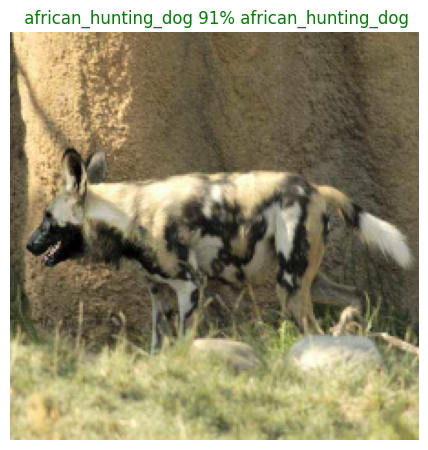

In [72]:
plot_pred(prediction_probabilities=predictions, labels = val_labels, images = val_images, n = 17)

Making it for top 10 predictions
The functoin will

*   take an input of prediction probabilities array and a ground truth array and an integer.
*   Find the prediction using 'get_pred_label()'
* Find the top 10:
* Prediction probabilities indexes
* prediction labels
* plot the top 10 prediction probability values and labels, colouring the true label green




In [73]:
def plot_pred_conf(prediction_probabilities, labels, n= 1):
  """
  Plus the top 10 highest prediction confidences along with the truth label for sample n.
  """

  pred_prob, true_label = prediction_probabilities[n], labels[n]
  pred_label = get_pred_label(pred_prob)

  # Find the top 10 predictions
  top_10_pred_indexes = pred_prob.argsort()[-10:][:: -1]
  #find the top 10 prediction confidence values
  top_10_pred_values = pred_prob[top_10_pred_indexes]

  top_10_pred_labels = unique_breeds[top_10_pred_indexes]

  # Setup plot
  top_plot = plt.bar(np.arange(len(top_10_pred_labels)),
                     top_10_pred_values,
                     color = "grey")
  plt.xticks(np.arange(len(top_10_pred_labels)),
             labels = top_10_pred_labels,
             rotation = "vertical")
  #change colour of true label
  if np.isin(true_label, top_10_pred_labels):
    top_plot[np.argmax(top_10_pred_labels == true_label)].set_color("green")
  else:
    pass





In [74]:
predictions[0].argsort()[-10:][::-1] #argsort arranges the indices in ascending order . so access last 10 and reverse that to get the top 1st to 10th indexes

array([ 17,  26,  35,  59, 102, 103,  73,  79, 109, 106])

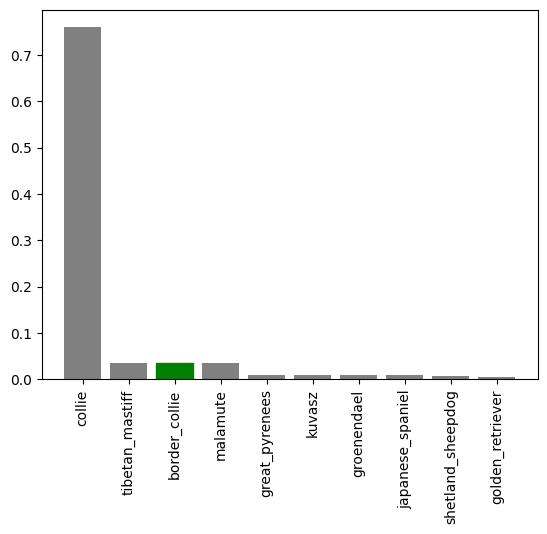

In [75]:
plot_pred_conf(prediction_probabilities=predictions, labels = val_labels, n = 9)

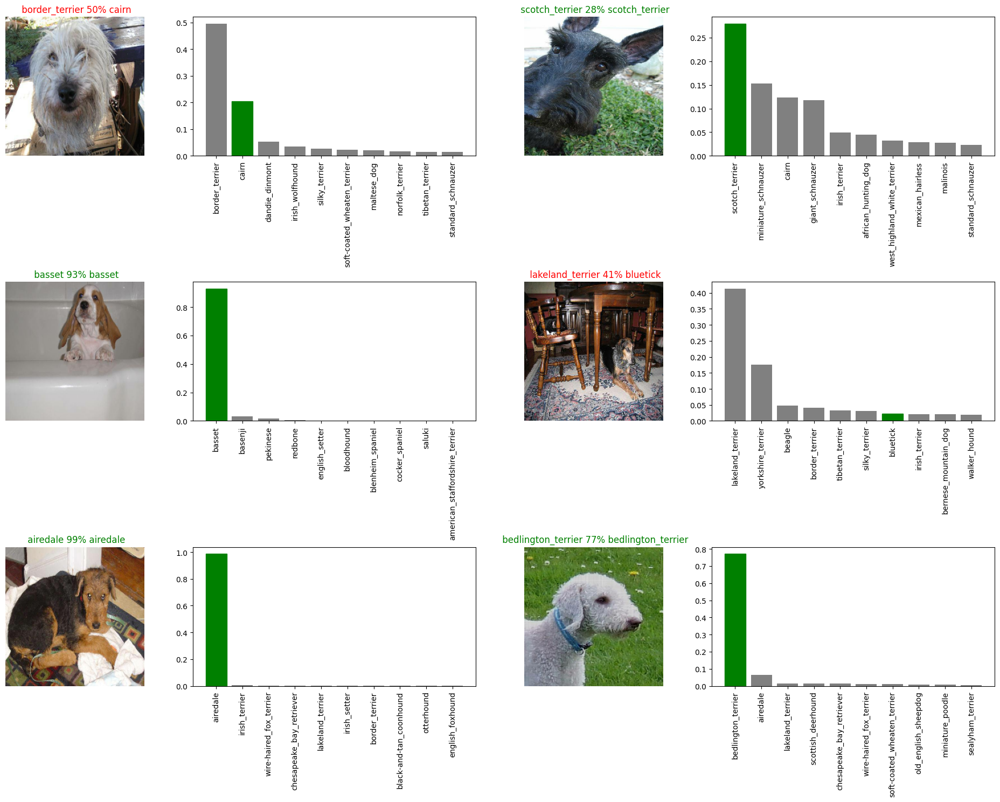

In [76]:

i_multiplier  = 0
num_rows = 3
num_cols = 2
num_images = num_rows * num_cols

plt.figure(figsize = (10*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_pred(prediction_probabilities=predictions, labels = val_labels, images = val_images, n = i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=predictions, labels = val_labels, n = i+i_multiplier)
plt.tight_layout(h_pad = 1.0)
plt.show()

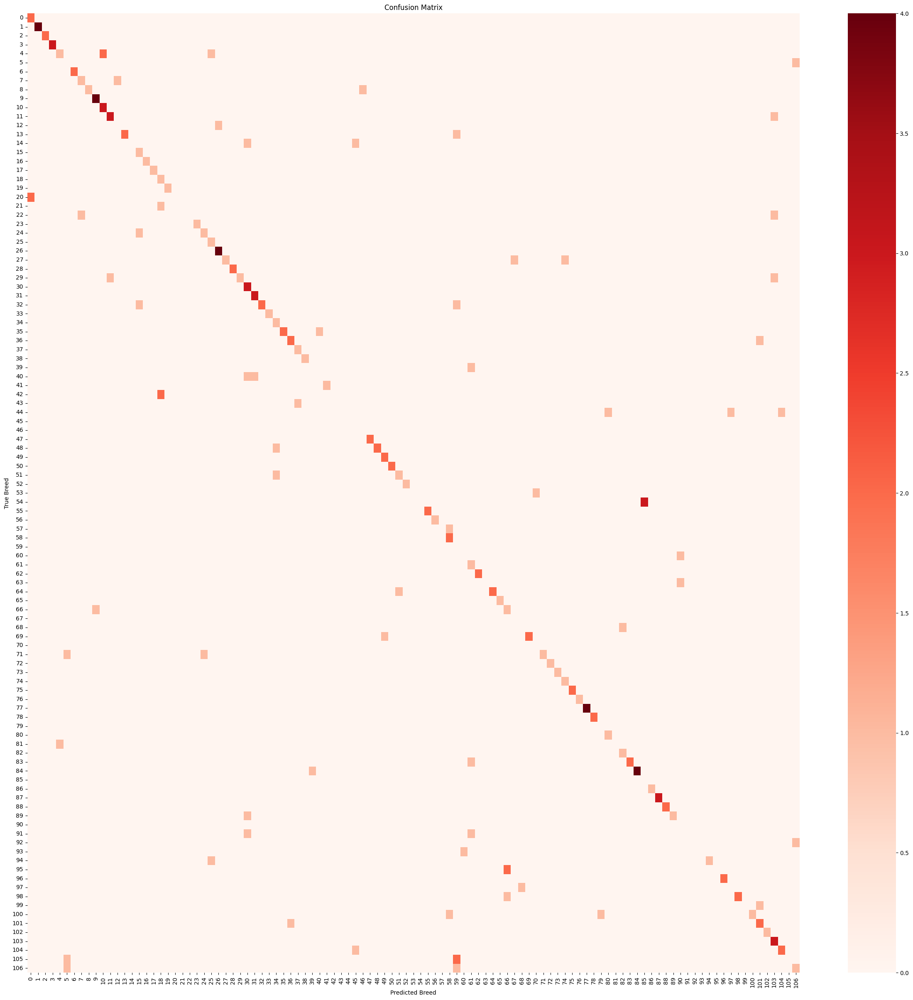

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_indices = np.argmax(predictions, axis = 1)
y_pred_labels = unique_breeds[y_pred_indices]
y_true_labels = val_labels
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize = (30,30))
sns.heatmap(cm, annot = False, cmap = "Reds")
plt.xlabel("Predicted Breed")
plt.ylabel("True Breed")
plt.title("Confusion Matrix")
plt.show()

Saving and reloading a trained model

In [78]:
def save_model(model, suffix = None):
  """
  Saves a given model in a models directory and appends a suffix (string):
  """
  modeldir = os.path.join("/content/drive/MyDrive/dog_breed_data/models", datetime.datetime.now().strftime("%Y%m%d-%H%M%s"))
  model_path = modeldir + "-" + suffix + ".h5" #save format of model
  print(f"Saving model to: {model_path}...")
  model.save(model_path)
  return model_path

In [79]:
# Function to load a model

def load_model(model_path):
  print(f"Loading saved model from: {model_path}")
  model = tf.keras.models.load_model(model_path, custom_objects = {"KerasLayer": hub.KerasLayer})
  return model


In [80]:
save_model(model, suffix = "1000-images-mobilnetv2-Adam")

Saving model to: /content/drive/MyDrive/dog_breed_data/models/20261009-06581791529106-1000-images-mobilnetv2-Adam.h5...


/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


'/content/drive/MyDrive/dog_breed_data/models/20261009-06581791529106-1000-images-mobilnetv2-Adam.h5'

In [81]:
loaded_1000_image_model = load_model("/content/drive/MyDrive/dog_breed_data/models/20261008-12551791464122-1000-images-mobilnetv2-Adam.h5")

Loading saved model from: /content/drive/MyDrive/dog_breed_data/models/20261008-12551791464122-1000-images-mobilnetv2-Adam.h5


In [82]:
model.evaluate(val_data)

7/7 [==============================] - 1s 104ms/step - loss: 1.2618 - accuracy: 0.6400


[1.2618162631988525, 0.6399999856948853]

In [83]:
loaded_1000_image_model.evaluate(val_data)

7/7 [==============================] - 2s 121ms/step - loss: 1.2346 - accuracy: 0.6800


[1.234566330909729, 0.6800000071525574]

In [84]:
len(X), len(y), len(X_train)

(10222, 10222, 800)

In [85]:
# Create a databatch with the full data set
full_data = create_data_batches(X, y)
full_data

Creating for training data batches...


<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [86]:
# Create a model for full data
full_model = create_model()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4


In [87]:
# Create full model callbacks
full_model_tensorboard = create_tensorboard_callback()
# No validation set when training on all the data, so we cant monitor validdation accuracy
full_model_early_stopping = tf.keras.callbacks.EarlyStopping(monitor = "accuracy", patience = 3)

**Note:** Running the below cell below takes a long time. upto 30min for the first epoch.

In [88]:
full_model.fit(x = full_data,
               epochs = NUM_EPOCHS,
               callbacks = [full_model_tensorboard, full_model_early_stopping])


Epoch 1/100
320/320 [==============================] - 37s 104ms/step - loss: 1.3398 - accuracy: 0.6702
Epoch 2/100
320/320 [==============================] - 29s 90ms/step - loss: 0.4043 - accuracy: 0.8781
Epoch 3/100
320/320 [==============================] - 28s 88ms/step - loss: 0.2399 - accuracy: 0.9342
Epoch 4/100
320/320 [==============================] - 39s 123ms/step - loss: 0.1521 - accuracy: 0.9629
Epoch 5/100
320/320 [==============================] - 29s 89ms/step - loss: 0.1070 - accuracy: 0.9785
Epoch 6/100
320/320 [==============================] - 28s 88ms/step - loss: 0.0770 - accuracy: 0.9856
Epoch 7/100
320/320 [==============================] - 28s 88ms/step - loss: 0.0594 - accuracy: 0.9916
Epoch 8/100
320/320 [==============================] - 28s 89ms/step - loss: 0.0453 - accuracy: 0.9953
Epoch 9/100
320/320 [==============================] - 27s 85ms/step - loss: 0.0385 - accuracy: 0.9949
Epoch 10/100
320/320 [==============================] - 27s 85ms/step -

In [89]:
save_model(full_model, suffix = "full-image-set-mobilenetv2")

Saving model to: /content/drive/MyDrive/dog_breed_data/models/20261009-07081791529695-full-image-set-mobilenetv2.h5...


'/content/drive/MyDrive/dog_breed_data/models/20261009-07081791529695-full-image-set-mobilenetv2.h5'

In [90]:
loaded_full_model = load_model("/content/drive/MyDrive/dog_breed_data/models/20261008-15541791474883-full-image-set-mobilenetv2.h5")

Loading saved model from: /content/drive/MyDrive/dog_breed_data/models/20261008-15541791474883-full-image-set-mobilenetv2.h5


##Making predictions on Test Data

Since the model is trained on images in the form of Tensor batches, to make predictions on the test data, we'll have to get it into same format

To make predictions on the test data:
* Get the test image filenames
* convert the filenames into the test data batches using create_data_batches() custom function and setting test_data parameter as True (since the test data dont have any labels).
* Make a predictions array by test batches to the predict() method called on our model.

In [91]:
test_path = "drive/MyDrive/dog_breed_data/test/"
test_filenames = [test_path + fname for fname in os.listdir(test_path)]
test_filenames[:10]

['drive/MyDrive/dog_breed_data/test/dfc0659b3b6eff35dc50d2501f1ea247.jpg',
 'drive/MyDrive/dog_breed_data/test/e67b8da61ba5b55bcc01200ab057c7b0.jpg',
 'drive/MyDrive/dog_breed_data/test/dd2228d2fbb3ddc8fb350106c2d989ef.jpg',
 'drive/MyDrive/dog_breed_data/test/e7f95aabf775a636b3893ffa120adaf9.jpg',
 'drive/MyDrive/dog_breed_data/test/e683ba5a138de0fbb7bb1523862b43f2.jpg',
 'drive/MyDrive/dog_breed_data/test/dd703c7beeaf5cba5533d5f42b608f2e.jpg',
 'drive/MyDrive/dog_breed_data/test/dd9d222a481e6cbea922a1b601a55a38.jpg',
 'drive/MyDrive/dog_breed_data/test/df4b040b13c5f514d215ba7c0813eaf8.jpg',
 'drive/MyDrive/dog_breed_data/test/e774fbfeb4b712ca042f93edea3835af.jpg',
 'drive/MyDrive/dog_breed_data/test/dd8c716a81edb1cac3d4cb2b6c47880a.jpg']

In [92]:
len(test_filenames)

10357

In [93]:
#create a test data batches

test_data = create_data_batches(test_filenames, test_data = True)

Creating test data batches...


In [94]:
test_data

<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

**Note**: Calling this below cell might take a long time upto 1 hr or more.

In [95]:
#Make predictions on test data batch using loaded full model
test_predictions = loaded_full_model.predict(test_data, verbose = 1)

324/324 [==============================] - 203s 607ms/step


In [96]:
np.savetxt("/content/drive/MyDrive/dog_breed_data/predictions_array.csv", test_predictions, delimiter=",")

In [97]:
pred_df = pd.DataFrame(columns = ["id"] + list(unique_breeds))
pred_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier


In [99]:
test_ids = [os.path.splitext(path)[0] for path in os.listdir(test_path)]
test_ids[:10]

['dfc0659b3b6eff35dc50d2501f1ea247',
 'e67b8da61ba5b55bcc01200ab057c7b0',
 'dd2228d2fbb3ddc8fb350106c2d989ef',
 'e7f95aabf775a636b3893ffa120adaf9',
 'e683ba5a138de0fbb7bb1523862b43f2',
 'dd703c7beeaf5cba5533d5f42b608f2e',
 'dd9d222a481e6cbea922a1b601a55a38',
 'df4b040b13c5f514d215ba7c0813eaf8',
 'e774fbfeb4b712ca042f93edea3835af',
 'dd8c716a81edb1cac3d4cb2b6c47880a']

In [101]:
pred_df["id"] = test_ids
pred_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,dfc0659b3b6eff35dc50d2501f1ea247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e67b8da61ba5b55bcc01200ab057c7b0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dd2228d2fbb3ddc8fb350106c2d989ef,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e7f95aabf775a636b3893ffa120adaf9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,e683ba5a138de0fbb7bb1523862b43f2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
pred_df[list(unique_breeds)] = test_predictions
pred_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,dfc0659b3b6eff35dc50d2501f1ea247,5.167924e-10,5.511256e-10,5.546419e-12,6.497425e-04,1.107840e-02,1.505124e-03,1.359499e-03,5.978186e-08,3.211128e-09,...,1.024899e-08,1.157515e-05,1.831004e-07,1.321334e-04,1.745597e-07,4.574525e-06,7.915007e-08,6.340922e-11,5.828526e-09,2.734665e-04
1,e67b8da61ba5b55bcc01200ab057c7b0,6.239464e-06,2.435270e-09,1.943309e-08,6.073684e-10,1.899570e-07,1.888147e-10,9.240614e-07,9.440741e-09,8.642170e-09,...,9.350855e-08,1.099324e-08,1.471468e-09,3.165969e-06,1.674078e-08,1.516952e-10,2.821835e-05,3.389225e-09,1.897480e-04,2.949486e-07
2,dd2228d2fbb3ddc8fb350106c2d989ef,7.814630e-09,5.886265e-11,1.160274e-09,1.516940e-07,4.045728e-08,1.026740e-10,6.920227e-04,8.987415e-09,1.665186e-09,...,8.546382e-08,3.940756e-04,4.729141e-08,1.457877e-09,1.334785e-10,6.990366e-11,1.228891e-05,2.389481e-09,3.174898e-08,1.320919e-05
3,e7f95aabf775a636b3893ffa120adaf9,7.777079e-01,4.645178e-10,1.149801e-08,1.950000e-11,7.681928e-09,4.210397e-11,8.801963e-08,2.358000e-09,2.906158e-10,...,2.883835e-05,3.814441e-08,9.235578e-09,1.335966e-09,1.552944e-08,3.372074e-11,2.386344e-10,2.587625e-11,2.575216e-08,4.256901e-05
4,e683ba5a138de0fbb7bb1523862b43f2,1.415188e-08,6.343435e-06,4.346894e-09,2.277325e-10,1.494792e-10,4.001815e-12,2.952007e-09,9.575392e-07,9.246451e-12,...,1.560264e-01,9.249372e-10,2.491671e-07,1.666873e-11,2.328474e-09,4.649738e-11,3.526975e-10,6.253900e-11,2.513190e-09,9.094447e-10


In [105]:

pred_df.to_csv("/content/drive/MyDrive/dog_breed_data/final_model_predictions.csv", index = False)

## Making predictions on custom inputs

* Get the filepaths of custom photos
* Turn the filepaths into databatches using create_data_batches and since our custom iamges dont have labels, we set the test_data parameter to true

* pass the custom image data batch to our model's preedict() method.
* convert the prediction output probabilities to prediction labels.

In [117]:
custom_path = "/content/drive/MyDrive/dog_breed_data/custom_images/"
custom_image_paths = [custom_path + fname for fname in os.listdir(custom_path)]

In [118]:
custom_image_paths

['/content/drive/MyDrive/dog_breed_data/custom_images/🐾 Adorable Golden Retriever Puppy _ Fluffy, Happy, and Playful!.jpg',
 '/content/drive/MyDrive/dog_breed_data/custom_images/download (2).jpg',
 '/content/drive/MyDrive/dog_breed_data/custom_images/Cute Dog pet.jpg']

In [119]:
custom_data = create_data_batches(custom_image_paths, test_data = True)
custom_data

Creating test data batches...


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [120]:
custom_preds = loaded_full_model.predict(custom_data)

1/1 [==============================] - 1s 921ms/step


In [122]:
#Get custom image prediction labels
custom_pred_labels = [get_pred_label(custom_preds[i]) for i in range(len(custom_preds))]
custom_pred_labels

['golden_retriever', 'golden_retriever', 'pomeranian']

In [123]:
custom_images = []
for image in custom_data.unbatch().as_numpy_iterator():
  custom_images.append(image)

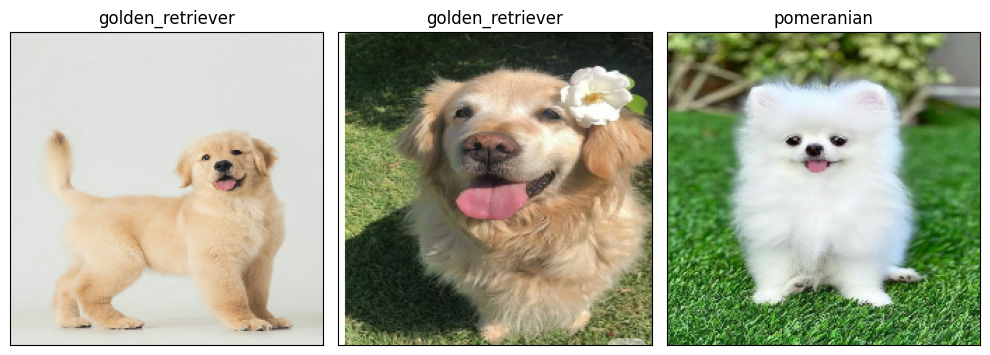

In [125]:
#custom_image_predictions
plt.figure(figsize = (10, 10))
for i, image in enumerate(custom_images):
  plt.subplot(1, 3, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.title(custom_pred_labels[i])
  plt.imshow(image)
plt.tight_layout()
plt.show()
